# 04 — Backtesting cronológico

## Objetivo

Este notebook implementa el protocolo de backtesting definido previamente para
comparar métodos tradicionales de Desarrollo y, posteriormente, modelos de
Machine Learning bajo las mismas condiciones temporales.

El objetivo es reproducir una situación real de reservación:

1. se fija una fecha histórica de valuación del modelo;
2. únicamente se utiliza información disponible hasta dicha fecha;
3. se identifican las cohortes que aún no han alcanzado `dev_M`;
4. se genera una predicción de su Loss Incurred a madurez;
5. la predicción queda congelada;
6. posteriormente se revela el valor real observado en `dev_M`;
7. todas las metodologías se comparan sobre exactamente las mismas claves.

La característica fundamental del experimento es que `target_amount` nunca
participa en la construcción de las predicciones.

La base simulada contiene la trayectoria completa de desarrollo de cada cohorte.
Esto permite evaluar históricamente también observaciones con edades tempranas
de desarrollo, aun cuando su `target_period` ocurra después de `FINAL_PERIOD`,
sin introducir información futura en los modelos.

## 1. Reglas del experimento

El backtesting se realiza independientemente para los tres escenarios simulados:

- `creciente`: `dev_M = 60`
- `decreciente`: `dev_M = 48`
- `mixto`: `dev_M = 48`

Las fechas históricas de valuación son mensuales desde `2020-01` hasta
`2025-11`.

Para cada combinación

\[
(\text{scenario},\ \text{model valuation period},\ \text{accident period})
\]

la información disponible queda determinada exclusivamente por la fecha
histórica de valuación.

### Separación entre entrenamiento y predicción

Para una fecha de valuación \(t\):

**Entrenamiento**

Solo pueden utilizarse cohortes cuyo `target_period` ya haya ocurrido:

\[
target\_period \le t
\]

**Predicción**

Se utilizan cohortes observables pero todavía inmaduras:

\[
target\_period > t
\]

y, equivalentemente,

\[
0 \le snapshot\_dev\_month < dev_M
\]

`target_period` puede conocerse antes de la evaluación porque es una fecha
estructural determinada por `accident_period` y `dev_M`.

En cambio, `target_amount` permanece oculto hasta que las predicciones han sido
generadas y congeladas.

`FINAL_PERIOD` se utiliza únicamente como diagnóstico; no determina la
elegibilidad de las cohortes de predicción.

### Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: c:\Users\derec\Desktop\Proyectos\Modelado_Reservas_ML_vs_metodos_Actuariales


In [3]:
from src.experiment.config import (
    DEV_M,
    VALUATION_PERIODS,
    FINAL_PERIOD,
    DEVELOPMENT_ALTERNATIVES,
)

from src.experiment.snapshots import (
    build_train_prediction_snapshots,
)

from src.experiment.backtesting import (
    run_development_backtest_valuation,
)

from src.simulation import (
    SimulationConfig,
    simulate_all_scenarios,
)

In [4]:
simulation_config = SimulationConfig()

simulations_base = simulate_all_scenarios(
    simulation_config
)

print(simulations_base.keys())

for scenario_name, df in simulations_base.items():
    print(
        f"{scenario_name:12s} | "
        f"{len(df):,} filas | "
        f"{df['accident_period'].min()} → {df['accident_period'].max()} | "
        f"dev_M = {DEV_M[scenario_name]}"
    )

dict_keys(['creciente', 'decreciente', 'mixto'])
creciente    | 8,052 filas | 2015-01 → 2025-12 | dev_M = 60
decreciente  | 6,468 filas | 2015-01 → 2025-12 | dev_M = 48
mixto        | 6,468 filas | 2015-01 → 2025-12 | dev_M = 48


## 2. Configuración experimental congelada

Las decisiones de diseño no se optimizan durante el backtesting.

Los horizontes de madurez, fechas de valuación y alternativas de Desarrollo
fueron definidos antes de observar los resultados del backtesting.

Esto evita modificar el experimento en respuesta al desempeño observado.

In [5]:
DEV_M

{'creciente': 60, 'decreciente': 48, 'mixto': 48}

In [6]:
print(f"Número de valuaciones: {len(VALUATION_PERIODS)}")
print(f"Primera valuación:       {VALUATION_PERIODS[0]}")
print(f"Última valuación:        {VALUATION_PERIODS[-1]}")
print(f"Periodo final:           {FINAL_PERIOD}")

Número de valuaciones: 71
Primera valuación:       2020-01
Última valuación:        2025-11
Periodo final:           2025-12


In [7]:
print(
    f"Alternativas de Desarrollo: "
    f"{len(DEVELOPMENT_ALTERNATIVES)}"
)

Alternativas de Desarrollo: 21


In [8]:
pd.DataFrame(DEVELOPMENT_ALTERNATIVES)

,0,1,2
0,S,24,none
1,S,24,minmax
2,S,24,std2
3,S,all,none
4,S,all,minmax
5,S,all,std2
6,VW,24,none
7,VW,24,minmax
8,VW,24,std2
9,VW,all,none


## 3. Snapshots históricos

Para cada fecha de valuación se construyen dos universos independientes.

### Snapshot de entrenamiento

Contiene exclusivamente cohortes cuyo Loss Incurred en `dev_M` ya era
observable en la fecha histórica de valuación:

\[
target\_period \le model\_valuation\_period
\]

Estas observaciones pueden utilizarse para estimar parámetros porque su objetivo
ya era conocido históricamente.

### Snapshot de predicción

Contiene las cohortes que:

1. ya existen y son observables en la fecha de valuación; y
2. todavía no han alcanzado `dev_M`.

Por tanto:

\[
0 \le snapshot\_dev\_month < dev_M
\]

y:

\[
target\_period > model\_valuation\_period
\]

La elegibilidad **no depende** de que el objetivo se revele antes de
`FINAL_PERIOD`. Esto permite conservar las edades jóvenes.

El snapshot de predicción puede contener `target_period`, porque esta fecha es
estructural, pero no contiene `target_amount`.

Esta separación constituye la principal barrera contra leakage temporal.

In [9]:
def snapshot_summary(
    train: pd.DataFrame,
    prediction: pd.DataFrame,
    *,
    scenario: str,
    model_valuation_period,
) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "scenario": [scenario],
            "model_valuation_period": [model_valuation_period],
            "dev_M": [DEV_M[scenario]],
            "train_rows": [len(train)],
            "train_cohorts": [
                train["accident_period"].nunique()
            ],
            "prediction_cohorts": [
                prediction["accident_period"].nunique()
            ],
            "prediction_age_min": [
                prediction["snapshot_dev_month"].min()
                if len(prediction)
                else np.nan
            ],
            "prediction_age_max": [
                prediction["snapshot_dev_month"].max()
                if len(prediction)
                else np.nan
            ],
        }
    )

### Valuación de prueba

Antes de ejecutar el orquestador completo se inspecciona una sola fecha
histórica para corroborar la separación entre entrenamiento y predicción.

In [10]:
scenario = "creciente"
model_valuation_period = pd.Period(
    "2022-06",
    freq="M",
)

df_scenario = simulations_base[scenario]

In [11]:
train_snapshot, prediction_snapshot = (
    build_train_prediction_snapshots(
        df=df_scenario,
        scenario=scenario,
        valuation_period=model_valuation_period,
    )
)

In [12]:
display(
    snapshot_summary(
        train_snapshot,
        prediction_snapshot,
        scenario=scenario,
        model_valuation_period=model_valuation_period,
    )
)

assert "target_amount" in train_snapshot.columns
assert "target_amount" not in prediction_snapshot.columns

assert (
    train_snapshot["target_period"]
    <= model_valuation_period
).all()

assert (
    prediction_snapshot["target_period"]
    > model_valuation_period
).all()

assert (
    prediction_snapshot["snapshot_dev_month"]
    < DEV_M[scenario]
).all()

print("✓ Separación train/prediction correcta")
print("✓ Prediction snapshot sin target_amount")
print("✓ target_period es posterior a la valuación del modelo")

,scenario,model_valuation_period,dev_M,train_rows,train_cohorts,prediction_cohorts,prediction_age_min,prediction_age_max
0,creciente,2022-06,60,1800,30,60,0,59


✓ Separación train/prediction correcta
✓ Prediction snapshot sin target_amount
✓ target_period es posterior a la valuación del modelo


## 4. Backtesting de una valuación histórica

La lógica del backtesting se encuentra implementada y validada en
`src.experiment.backtesting`.

Para una fecha histórica de valuación, el flujo completo es:

1. construir los snapshots de entrenamiento y predicción;
2. ajustar las 21 alternativas del Método de Desarrollo;
3. generar predicciones para las mismas cohortes;
4. congelar las predicciones antes de conocer `target_amount`;
5. revelar posteriormente el Loss Incurred real en `dev_M`;
6. verificar la integridad temporal de la evaluación;
7. calcular errores individuales y métricas por alternativa.

La fecha `FINAL_PERIOD` se utiliza únicamente como diagnóstico y no participa
en la selección de cohortes.

Como validación inicial se ejecuta el proceso completo para el escenario
`creciente` en `2022-06`.

In [13]:
pilot_result = run_development_backtest_valuation(
    df=df_scenario,
    scenario=scenario,
    model_valuation_period=model_valuation_period,
    dev_M=DEV_M[scenario],
    alternatives=DEVELOPMENT_ALTERNATIVES,
    final_period=FINAL_PERIOD,
)

### 4.1 Resumen de la valuación

In [14]:
pilot_summary = pd.DataFrame(
    {
        "scenario": [
            pilot_result.scenario
        ],
        "model_valuation_period": [
            pilot_result.model_valuation_period
        ],
        "dev_M": [
            DEV_M[scenario]
        ],
        "train_rows": [
            len(pilot_result.train_snapshot)
        ],
        "train_cohorts": [
            pilot_result.train_snapshot[
                "accident_period"
            ].nunique()
        ],
        "prediction_cohorts": [
            pilot_result.prediction_snapshot[
                "accident_period"
            ].nunique()
        ],
        "development_methods": [
            pilot_result.frozen_predictions[
                "method_name"
            ].nunique()
        ],
        "frozen_predictions": [
            len(pilot_result.frozen_predictions)
        ],
        "evaluated_predictions": [
            len(pilot_result.evaluated_predictions)
        ],
    }
)

display(pilot_summary)

assert (
    pilot_result.frozen_predictions[
        "method_name"
    ].nunique()
    == len(DEVELOPMENT_ALTERNATIVES)
)

assert (
    len(pilot_result.frozen_predictions)
    ==
    len(pilot_result.prediction_snapshot)
    * len(DEVELOPMENT_ALTERNATIVES)
)

assert (
    len(pilot_result.evaluated_predictions)
    ==
    len(pilot_result.frozen_predictions)
)

print("✓ Valuación histórica ejecutada correctamente")

,scenario,model_valuation_period,dev_M,train_rows,train_cohorts,prediction_cohorts,development_methods,frozen_predictions,evaluated_predictions
0,creciente,2022-06,60,1800,30,60,21,1260,1260


✓ Valuación histórica ejecutada correctamente


### 4.2 Separación entre predicción y evaluación

Las predicciones congeladas contienen la información estructural conocida en la
fecha histórica de valuación, incluido `target_period`.

La fecha futura en la que una cohorte alcanzará `dev_M` es determinística:

\[
target\_period = accident\_period + dev_M
\]

Por ello puede estar presente durante la predicción.

El Loss Incurred que se observará en esa fecha (`target_amount`) permanece
oculto hasta la etapa de evaluación.

In [15]:
assert (
    "target_amount"
    not in pilot_result.frozen_predictions.columns
)

assert (
    "target_period"
    in pilot_result.frozen_predictions.columns
)

assert (
    "target_amount"
    in pilot_result.evaluated_predictions.columns
)

assert (
    pilot_result.evaluated_predictions[
        "target_period"
    ]
    >
    pilot_result.evaluated_predictions[
        "model_valuation_period"
    ]
).all()

print("✓ target_amount permanece oculto durante la predicción")
print("✓ target_period es información estructural conocida")
print("✓ Todos los targets pertenecen al futuro de la valuación")

✓ target_amount permanece oculto durante la predicción
✓ target_period es información estructural conocida
✓ Todos los targets pertenecen al futuro de la valuación


### 4.3 Cohortes y edades evaluadas

Una de las correcciones centrales del diseño es que las edades jóvenes permanecen
en la población de predicción, aun cuando su objetivo se revele después de
`FINAL_PERIOD`.

In [16]:
age_summary = (
    pilot_result.prediction_snapshot[
        "snapshot_dev_month"
    ]
    .describe()
    .to_frame(
        name="snapshot_dev_month"
    )
)

display(age_summary)

assert (
    pilot_result.prediction_snapshot[
        "snapshot_dev_month"
    ].min()
    == 0
)

print(
    "✓ El backtesting incluye cohortes "
    "con edad de desarrollo 0"
)

,snapshot_dev_month
count,60.000000
mean,29.500000
std,17.464249
min,0.000000
25%,14.750000
50%,29.500000
75%,44.250000
max,59.000000


✓ El backtesting incluye cohortes con edad de desarrollo 0


In [17]:
experiment_end_summary = (
    pilot_result.evaluated_predictions
    .groupby(
        "target_revealed_by_experiment_end"
    )
    .agg(
        n_predictions=(
            "prediction",
            "size",
        ),
        n_cohorts=(
            "accident_period",
            "nunique",
        ),
        min_age=(
            "snapshot_dev_month",
            "min",
        ),
        max_age=(
            "snapshot_dev_month",
            "max",
        ),
    )
    .reset_index()
)

display(experiment_end_summary)

assert (
    ~pilot_result.evaluated_predictions[
        "target_revealed_by_experiment_end"
    ]
).any()

print(
    "✓ Cohortes con target posterior a FINAL_PERIOD "
    "permanecen en la evaluación"
)

,target_revealed_by_experiment_end,n_predictions,n_cohorts,min_age,max_age
0,False,378,18,0,17
1,True,882,42,18,59


✓ Cohortes con target posterior a FINAL_PERIOD permanecen en la evaluación


Las observaciones cuyo `target_period` ocurre después de `FINAL_PERIOD`
permanecen dentro de la evaluación.

Por tanto, `FINAL_PERIOD` ya no determina la elegibilidad de una cohorte para el
backtesting. Su función es únicamente identificar qué observaciones habrían
quedado excluidas bajo el diseño anterior.

Este cambio permite evaluar correctamente las edades jóvenes.

### 4.4 Predicciones de Desarrollo

In [18]:
display(
    pilot_result.frozen_predictions[
        [
            "scenario",
            "model_valuation_period",
            "accident_period",
            "snapshot_dev_month",
            "observed_amount",
            "target_period",
            "method_name",
            "development_cdf",
            "prediction",
        ]
    ]
    .head(10)
)

,scenario,model_valuation_period,accident_period,snapshot_dev_month,observed_amount,target_period,method_name,development_cdf,prediction
0,creciente,2022-06,2017-07,59,1.287898e+06,2022-07,S_24_none,1.002296,1.290855e+06
1,creciente,2022-06,2017-08,58,1.028391e+06,2022-08,S_24_none,1.004101,1.032608e+06
2,creciente,2022-06,2017-09,57,9.798969e+05,2022-09,S_24_none,1.006031,9.858063e+05
3,creciente,2022-06,2017-10,56,9.494943e+05,2022-10,S_24_none,1.008165,9.572468e+05
4,creciente,2022-06,2017-11,55,1.069083e+06,2022-11,S_24_none,1.005936,1.075429e+06
5,creciente,2022-06,2017-12,54,1.186681e+06,2022-12,S_24_none,1.010287,1.198889e+06
6,creciente,2022-06,2018-01,53,1.113111e+06,2023-01,S_24_none,1.015862,1.130767e+06
7,creciente,2022-06,2018-02,52,1.090384e+06,2023-02,S_24_none,1.014831,1.106555e+06
8,creciente,2022-06,2018-03,51,1.118690e+06,2023-03,S_24_none,1.013474,1.133764e+06
9,creciente,2022-06,2018-04,50,1.269268e+06,2023-04,S_24_none,1.015673,1.289161e+06


Para una cohorte observada en edad \(d\), el Método de Desarrollo proyecta:

\[
\widehat{L}_M
=
L_d \times CDF_d
=
L_d
\prod_{j=d}^{M-1}\widehat{f}_j
\]

La siguiente comprobación reproduce manualmente una de las predicciones.

In [19]:
example = (
    pilot_result.frozen_predictions
    .iloc[0]
)

manual_prediction = (
    example["observed_amount"]
    * example["development_cdf"]
)

np.testing.assert_allclose(
    manual_prediction,
    example["prediction"],
    rtol=1e-12,
)

print(
    f"Observed amount:     "
    f"{example['observed_amount']:,.2f}"
)
print(
    f"Development CDF:     "
    f"{example['development_cdf']:.6f}"
)
print(
    f"Manual prediction:   "
    f"{manual_prediction:,.2f}"
)
print(
    f"Model prediction:    "
    f"{example['prediction']:,.2f}"
)

print(
    "\n✓ Predicción actuarial "
    "reproducida manualmente"
)

Observed amount:     1,287,898.33
Development CDF:     1.002296
Manual prediction:   1,290,854.84
Model prediction:    1,290,854.84

✓ Predicción actuarial reproducida manualmente


## 5. Evaluación de la valuación piloto

Después de congelar las predicciones se revelan los valores reales en `dev_M`.

Para cada predicción se define:

\[
e_i = \hat{y}_i-y_i
\]

por lo que:

- \(e_i > 0\): sobreestimación;
- \(e_i < 0\): subestimación.

Las métricas utilizadas inicialmente son:

- MAE;
- RMSE;
- MAPE;
- bias;
- bias relativo.

Todos los métodos se evalúan sobre exactamente las mismas cohortes y contra el
mismo `target_amount`.

In [20]:
display(
    pilot_result.evaluated_predictions[
        [
            "accident_period",
            "snapshot_dev_month",
            "method_name",
            "prediction",
            "target_amount",
            "error",
            "relative_error",
        ]
    ]
    .head(10)
)

,accident_period,snapshot_dev_month,method_name,prediction,target_amount,error,relative_error
0,2017-07,59,S_24_none,1.290855e+06,1.304975e+06,-14119.781096,-0.010820
1,2017-08,58,S_24_none,1.032608e+06,1.025095e+06,7513.361583,0.007329
2,2017-09,57,S_24_none,9.858063e+05,9.886748e+05,-2868.442936,-0.002901
3,2017-10,56,S_24_none,9.572468e+05,9.571200e+05,126.780328,0.000132
4,2017-11,55,S_24_none,1.075429e+06,1.089158e+06,-13728.548573,-0.012605
5,2017-12,54,S_24_none,1.198889e+06,1.174320e+06,24568.347529,0.020921
6,2018-01,53,S_24_none,1.130767e+06,1.111095e+06,19672.026983,0.017705
7,2018-02,52,S_24_none,1.106555e+06,1.093888e+06,12666.878653,0.011580
8,2018-03,51,S_24_none,1.133764e+06,1.129786e+06,3978.616790,0.003522
9,2018-04,50,S_24_none,1.289161e+06,1.288239e+06,922.541485,0.000716


### 5.1 Métricas por alternativa

In [21]:
development_metrics = (
    pilot_result.metrics
    .sort_values("mae")
    .reset_index(drop=True)
)

display(development_metrics)

,method_name,n_predictions,mae,rmse,mape,bias,relative_bias
0,VW_all_none,60,15030.764595,19354.115847,0.012171,3823.162944,0.003349
1,VW_36_none,60,15030.764595,19354.115847,0.012171,3823.162944,0.003349
2,VW_24_minmax,60,15038.687263,19132.681972,0.012173,3887.976573,0.003327
3,VW_24_none,60,15290.102500,19567.614198,0.012391,4110.805388,0.003622
4,VW_all_minmax,60,15459.154079,19668.221671,0.012548,5850.279490,0.004883
5,VW_24_std2,60,15763.822513,19881.488134,0.012758,2898.879298,0.002429
6,VW_12_none,60,15953.750552,20357.794666,0.013001,4665.565985,0.004130
7,M_all_minmax,60,16009.554105,20778.803426,0.013049,-8430.437186,-0.007110
8,M_all_none,60,16009.554105,20778.803426,0.013049,-8430.437186,-0.007110
9,VW_6_none,60,16113.373884,21034.246686,0.013232,5387.770138,0.004735


### 5.2 Comparabilidad de la evaluación

Antes de interpretar diferencias de desempeño, se verifica que las 21
alternativas hayan sido evaluadas sobre exactamente la misma población.

In [22]:
assert (
    development_metrics[
        "n_predictions"
    ].nunique()
    == 1
)

assert (
    development_metrics[
        "n_predictions"
    ].iloc[0]
    ==
    len(
        pilot_result.prediction_snapshot
    )
)

targets_per_cohort = (
    pilot_result.evaluated_predictions
    .groupby(
        "accident_period"
    )[
        "target_amount"
    ]
    .nunique()
)

assert (
    targets_per_cohort == 1
).all()

print(
    "✓ Las alternativas fueron evaluadas "
    "sobre exactamente las mismas cohortes"
)
print(
    "✓ Cada cohorte utiliza el mismo "
    "target_amount en todos los métodos"
)

✓ Las alternativas fueron evaluadas sobre exactamente las mismas cohortes
✓ Cada cohorte utiliza el mismo target_amount en todos los métodos


### 5.3 Estado de la valuación piloto

La valuación piloto completa ya reproduce el flujo cronológico requerido:

`train → predict → freeze → reveal → evaluate`.

La implementación detallada permanece en `src` y el notebook se limita a
documentar la metodología, ejecutar la API validada e interpretar sus salidas.

El siguiente paso será generalizar este mismo flujo a todas las fechas de
valuación y a los tres escenarios antes de incorporar la comparación con
Machine Learning.

## 6. Backtesting completo del Método de Desarrollo

Una vez validado el flujo sobre una valuación piloto y mediante pruebas
unitarias y de integración, se ejecuta el experimento cronológico completo.

El experimento comprende:

$$
3\ escenarios
\times
71\ fechas\ de\ valuación
=
213\ valuaciones\ históricas
$$

Para cada valuación se ejecutan las 21 alternativas del Método de Desarrollo,
por lo que se obtienen:

$$
213 \times 21 = 4\,473
$$

combinaciones de:

$$
(\text{scenario},
\text{model valuation period},
\text{method})
$$

Cada valuación reproduce independientemente la información que habría estado
disponible en ese momento histórico.

Las cohortes observables e inmaduras son proyectadas sin utilizar
`target_amount`. Posteriormente las predicciones se congelan, se revelan los
objetivos y se calculan los errores.

`FINAL_PERIOD` continúa utilizándose únicamente como diagnóstico y no como
criterio de elegibilidad.

In [23]:
from src.experiment.backtesting import (
    run_development_backtest_valuation,
    run_development_backtest_experiment,
)

### 6.1 Ejecutar el experimento

In [24]:
SCENARIOS = list(DEV_M.keys())

development_experiment = (
    run_development_backtest_experiment(
        simulations_base,
        scenarios=SCENARIOS,
        valuation_periods=VALUATION_PERIODS,
        dev_M_by_scenario=DEV_M,
        alternatives=DEVELOPMENT_ALTERNATIVES,
        final_period=FINAL_PERIOD,
    )
)

In [25]:
n_scenarios = len(SCENARIOS)
n_valuations = len(VALUATION_PERIODS)
n_methods = len(DEVELOPMENT_ALTERNATIVES)

expected_valuations = (
    n_scenarios
    * n_valuations
)

expected_metric_rows = (
    expected_valuations
    * n_methods
)

expected_factor_rows = (
    n_valuations
    * n_methods
    * sum(DEV_M.values())
)

print(f"Escenarios:                  {n_scenarios}")
print(f"Valuaciones por escenario:  {n_valuations}")
print(f"Valuaciones totales:         {expected_valuations}")
print(f"Alternativas:                {n_methods}")
print(f"Filas métricas esperadas:    {expected_metric_rows:,}")
print(f"Filas factores esperadas:    {expected_factor_rows:,}")

Escenarios:                  3
Valuaciones por escenario:  71
Valuaciones totales:         213
Alternativas:                21
Filas métricas esperadas:    4,473
Filas factores esperadas:    232,596


In [26]:
assert (
    len(
        development_experiment
        .valuation_summary
    )
    == expected_valuations
)

assert (
    len(
        development_experiment
        .valuation_metrics
    )
    == expected_metric_rows
)

assert (
    len(
        development_experiment
        .development_factors
    )
    == expected_factor_rows
)

assert (
    len(
        development_experiment
        .frozen_predictions
    )
    ==
    len(
        development_experiment
        .evaluated_predictions
    )
)

print("✓ 213 valuaciones históricas ejecutadas")
print("✓ 4,473 resultados método-valuación")
print("✓ Curvas de Desarrollo completas")
print("✓ Predicciones congeladas y evaluadas alineadas")

✓ 213 valuaciones históricas ejecutadas
✓ 4,473 resultados método-valuación
✓ Curvas de Desarrollo completas
✓ Predicciones congeladas y evaluadas alineadas


### Resumen de cobertura

In [27]:
valuation_summary = (
    development_experiment
    .valuation_summary
    .copy()
)

display(
    valuation_summary.head(10)
)

,scenario,model_valuation_period,n_train_rows,n_train_cohorts,n_prediction_cohorts,prediction_age_min,prediction_age_max,n_methods,n_predictions,prediction_fingerprint,n_target_by_experiment_end,n_target_after_experiment_end
0,creciente,2020-01,60,1,60,0,59,21,1260,480a9a97b1801ac72f285f5cccc54fa6d796dbf63289c5...,60,0
1,creciente,2020-02,120,2,60,0,59,21,1260,53dff5b849ba5fb4f399d0a82a2c60aa2048d22cca13c4...,60,0
2,creciente,2020-03,180,3,60,0,59,21,1260,1c9d3b0ea2192e6babfe0e68d9e7c5f292823fc195b59d...,60,0
3,creciente,2020-04,240,4,60,0,59,21,1260,4a6e3b324eb63cbfddde4802d2474c65bc81f1895ee405...,60,0
4,creciente,2020-05,300,5,60,0,59,21,1260,f755e08e7ff9e41457ab9de1c6295e90304ddd7afc61ee...,60,0
5,creciente,2020-06,360,6,60,0,59,21,1260,463e51fc9da8d6e40ee18045f3e767c2a7ad1d72b59641...,60,0
6,creciente,2020-07,420,7,60,0,59,21,1260,1f436a53e318431a798f99c0ca614906ffee8ca9f5d7a4...,60,0
7,creciente,2020-08,480,8,60,0,59,21,1260,6696289e0cf032247f236a3cf77791978653c1608b1248...,60,0
8,creciente,2020-09,540,9,60,0,59,21,1260,b7bef6c85cfd4b2b3a64ef1738768c346e16048c84d0ea...,60,0
9,creciente,2020-10,600,10,60,0,59,21,1260,d4ef2c3917e0dc5a8f640affdf8583321b74bbf0eb1902...,60,0


In [28]:
coverage_by_scenario = (
    valuation_summary
    .groupby("scenario")
    .agg(
        n_valuations=(
            "model_valuation_period",
            "nunique",
        ),
        first_valuation=(
            "model_valuation_period",
            "min",
        ),
        last_valuation=(
            "model_valuation_period",
            "max",
        ),
        min_prediction_age=(
            "prediction_age_min",
            "min",
        ),
        max_prediction_age=(
            "prediction_age_max",
            "max",
        ),
    )
    .reset_index()
)

display(coverage_by_scenario)

assert (
    coverage_by_scenario[
        "n_valuations"
    ]
    == len(VALUATION_PERIODS)
).all()

assert (
    coverage_by_scenario[
        "min_prediction_age"
    ]
    == 0
).all()

print("✓ Cobertura temporal completa")
print("✓ Los tres escenarios incluyen edad 0")

,scenario,n_valuations,first_valuation,last_valuation,min_prediction_age,max_prediction_age
0,creciente,71,2020-01,2025-11,0,59
1,decreciente,71,2020-01,2025-11,0,47
2,mixto,71,2020-01,2025-11,0,47


✓ Cobertura temporal completa
✓ Los tres escenarios incluyen edad 0


#### Interpretación de la cobertura

La cobertura temporal es completa: los tres escenarios contienen las 71 fechas
de valuación definidas entre `2020-01` y `2025-11`.

Además, el nuevo diseño conserva explícitamente la edad de desarrollo 0 en los
tres escenarios. El rango de edades coincide con cada horizonte de madurez:

- `creciente`: edades 0–59;
- `decreciente`: edades 0–47;
- `mixto`: edades 0–47.

La población de predicción permanece constante en cada fecha: 60 cohortes para
`creciente` y 48 para `decreciente` y `mixto`. Lo que aumenta con el tiempo es
la cantidad de historia madura disponible para estimar los modelos.

### Evolución de la población de entrenamiento y predicción

In [29]:
display(
    valuation_summary[
        [
            "scenario",
            "model_valuation_period",
            "n_train_cohorts",
            "n_prediction_cohorts",
            "prediction_age_min",
            "prediction_age_max",
            "n_target_by_experiment_end",
            "n_target_after_experiment_end",
        ]
    ]
    .head(20)
)

,scenario,model_valuation_period,n_train_cohorts,n_prediction_cohorts,prediction_age_min,prediction_age_max,n_target_by_experiment_end,n_target_after_experiment_end
0,creciente,2020-01,1,60,0,59,60,0
1,creciente,2020-02,2,60,0,59,60,0
2,creciente,2020-03,3,60,0,59,60,0
3,creciente,2020-04,4,60,0,59,60,0
4,creciente,2020-05,5,60,0,59,60,0
5,creciente,2020-06,6,60,0,59,60,0
6,creciente,2020-07,7,60,0,59,60,0
7,creciente,2020-08,8,60,0,59,60,0
8,creciente,2020-09,9,60,0,59,60,0
9,creciente,2020-10,10,60,0,59,60,0


In [30]:
population_summary = (
    valuation_summary
    .groupby("scenario")
    .agg(
        train_cohorts_min=(
            "n_train_cohorts",
            "min",
        ),
        train_cohorts_max=(
            "n_train_cohorts",
            "max",
        ),
        prediction_cohorts_min=(
            "n_prediction_cohorts",
            "min",
        ),
        prediction_cohorts_max=(
            "n_prediction_cohorts",
            "max",
        ),
        targets_after_end=(
            "n_target_after_experiment_end",
            "sum",
        ),
    )
    .reset_index()
)

display(population_summary)

,scenario,train_cohorts_min,train_cohorts_max,prediction_cohorts_min,prediction_cohorts_max,targets_after_end
0,creciente,1,71,60,60,1770
1,decreciente,13,83,48,48,1128
2,mixto,13,83,48,48,1128


#### Interpretación de la historia disponible

La cantidad de cohortes de entrenamiento crece de forma monotónica conforme
avanza la fecha de valuación.

En `creciente` pasa de 1 a 71 cohortes maduras, mientras que en `decreciente`
y `mixto` pasa de 13 a 83. Esta diferencia no representa una inconsistencia:
los dos últimos escenarios tienen un horizonte de madurez menor (`dev_M = 48`
frente a `dev_M = 60`), por lo que al inicio del backtesting ya existen más
cohortes cuyo objetivo es históricamente observable.

Esto también introduce un efecto de **cold start**. En particular, para
`creciente` en `2020-01` solo existe una cohorte madura de entrenamiento. Con
tan poca historia, ventanas, reglas de exclusión y métodos de agregación no
pueden diferenciarse de manera efectiva; por ello las 21 alternativas producen
el mismo resultado en esa primera valuación. Conforme aumenta la historia,
las alternativas comienzan a separarse.

### Verificar la separación temporal a escala completa

In [31]:
frozen_predictions = (
    development_experiment
    .frozen_predictions
)

evaluated_predictions = (
    development_experiment
    .evaluated_predictions
)

assert (
    "target_amount"
    not in frozen_predictions.columns
)

assert (
    "target_amount"
    in evaluated_predictions.columns
)

assert (
    frozen_predictions[
        "target_period"
    ]
    >
    frozen_predictions[
        "model_valuation_period"
    ]
).all()

assert (
    evaluated_predictions[
        "target_amount"
    ].notna().all()
)

print("✓ target_amount ausente durante todas las predicciones")
print("✓ Todos los targets son futuros respecto a su valuación")
print("✓ Todos los targets fueron revelados para evaluación")

✓ target_amount ausente durante todas las predicciones
✓ Todos los targets son futuros respecto a su valuación
✓ Todos los targets fueron revelados para evaluación


In [32]:
after_final_period = (
    ~evaluated_predictions[
        "target_revealed_by_experiment_end"
    ]
)

n_after_final_period = (
    evaluated_predictions.loc[
        after_final_period,
        [
            "scenario",
            "model_valuation_period",
            "accident_period",
        ],
    ]
    .drop_duplicates()
    .shape[0]
)

print(
    "Cohortes-valuación con target posterior "
    f"a FINAL_PERIOD: {n_after_final_period:,}"
)

assert after_final_period.any()

assert evaluated_predictions.loc[
    after_final_period,
    "error",
].notna().all()

print(
    "✓ Las observaciones posteriores a FINAL_PERIOD "
    "permanecen evaluadas"
)

Cohortes-valuación con target posterior a FINAL_PERIOD: 4,026
✓ Las observaciones posteriores a FINAL_PERIOD permanecen evaluadas


#### Impacto de la corrección de `FINAL_PERIOD`

El cambio respecto al diseño inicial no es marginal. En total existen **4,026
pares cohorte-valuación** cuyo `target_period` ocurre después de
`FINAL_PERIOD`, pero que ahora permanecen dentro del backtesting:

- 1,770 en `creciente`;
- 1,128 en `decreciente`;
- 1,128 en `mixto`.

Estas observaciones incluyen precisamente una parte importante de las edades
jóvenes y de las valuaciones más recientes. Mantenerlas permite evaluar el
problema que realmente se desea estudiar sin utilizar `FINAL_PERIOD` como un
filtro artificial de elegibilidad.

### 6.6 Resultados método-valuación

In [33]:
valuation_metrics = (
    development_experiment
    .valuation_metrics
    .copy()
)

display(
    valuation_metrics.head(20)
)

,scenario,model_valuation_period,method_name,n_predictions,mae,rmse,mape,bias,relative_bias
0,creciente,2020-01,M_24_minmax,60,17781.327717,24137.005544,0.015912,407.073231,0.000423
1,creciente,2020-01,M_24_none,60,17781.327717,24137.005544,0.015912,407.073231,0.000423
2,creciente,2020-01,M_24_std2,60,17781.327717,24137.005544,0.015912,407.073231,0.000423
3,creciente,2020-01,M_all_minmax,60,17781.327717,24137.005544,0.015912,407.073231,0.000423
4,creciente,2020-01,M_all_none,60,17781.327717,24137.005544,0.015912,407.073231,0.000423
5,creciente,2020-01,M_all_std2,60,17781.327717,24137.005544,0.015912,407.073231,0.000423
6,creciente,2020-01,S_24_minmax,60,17781.327717,24137.005544,0.015912,407.073231,0.000423
7,creciente,2020-01,S_24_none,60,17781.327717,24137.005544,0.015912,407.073231,0.000423
8,creciente,2020-01,S_24_std2,60,17781.327717,24137.005544,0.015912,407.073231,0.000423
9,creciente,2020-01,S_all_minmax,60,17781.327717,24137.005544,0.015912,407.073231,0.000423


#### Observación sobre las primeras valuaciones

La igualdad entre métodos en las primeras filas de `valuation_metrics` es
esperada. Por ejemplo, en `creciente` para `2020-01` las alternativas muestran
el mismo MAE porque el conjunto de entrenamiento contiene una sola cohorte
madura.

Por tanto, las diferencias entre configuraciones deben interpretarse junto con
la cantidad de historia disponible. Las primeras valuaciones evalúan no solo el
método actuarial, sino también su comportamiento bajo escasez extrema de
información.

In [34]:
metric_key = [
    "scenario",
    "model_valuation_period",
    "method_name",
]

assert not valuation_metrics.duplicated(
    metric_key
).any()

assert (
    valuation_metrics[
        "method_name"
    ].nunique()
    == 21
)

assert np.isfinite(
    valuation_metrics[
        [
            "mae",
            "rmse",
            "mape",
            "bias",
            "relative_bias",
        ]
    ].to_numpy()
).all()

print("✓ 4,473 evaluaciones método-valuación válidas")

✓ 4,473 evaluaciones método-valuación válidas


### Estado del experimento de Desarrollo

El backtesting actuarial completo produce ahora tres niveles de información:

**Nivel valuación**

Una observación por escenario y fecha histórica, utilizada para estudiar la
cobertura del experimento.

**Nivel método-valuación**

Una observación por escenario, fecha histórica y alternativa de Desarrollo,
utilizada para analizar desempeño y estabilidad temporal.

**Nivel predicción**

Una observación por escenario, fecha histórica, cohorte y método, utilizada
para estudiar el error en función de la edad de desarrollo.

Esta última granularidad es especialmente importante porque permite evaluar si
un método funciona de forma diferente cuando la cohorte tiene poca o mucha
información observada.

Por tanto, los resultados no se resumirán todavía mediante un único promedio
global. Primero se analizará el desempeño por escenario, fecha de valuación y
edad de desarrollo.

## 7. Análisis de resultados del Método de Desarrollo

El backtesting completo permite estudiar el desempeño de las 21 alternativas
actuariales desde distintas perspectivas.

No se utilizará únicamente un promedio global, ya que el desempeño puede variar
según:

- el escenario de desarrollo;
- la fecha histórica de valuación;
- la edad de desarrollo de la cohorte;
- la cantidad de información disponible.

El análisis se realizará progresivamente en cuatro niveles:

1. desempeño agregado por escenario y método;
2. estabilidad a través del tiempo;
3. desempeño por edad de desarrollo;
4. comportamiento del sesgo.

Esta descomposición permitirá construir un baseline actuarial suficientemente
detallado para la comparación posterior con Machine Learning.

### 7.1 Desempeño agregado por escenario

Primero trabajaremos con valuation_metrics, es decir, una observación por:

$$
(\text{scenario},
\text{model valuation period},
\text{method})
$$

In [35]:
valuation_metrics = (
    development_experiment
    .valuation_metrics
    .copy()
)

valuation_metrics.shape

(4473, 9)

In [36]:
assert len(valuation_metrics) == 4473

assert not valuation_metrics.duplicated(
    [
        "scenario",
        "model_valuation_period",
        "method_name",
    ]
).any()

print("✓ 4,473 resultados método-valuación disponibles")

✓ 4,473 resultados método-valuación disponibles


In [37]:
method_scenario_summary = (
    valuation_metrics
    .groupby(
        [
            "scenario",
            "method_name",
        ]
    )
    .agg(
        n_valuations=(
            "model_valuation_period",
            "nunique",
        ),

        mae_mean=(
            "mae",
            "mean",
        ),
        mae_median=(
            "mae",
            "median",
        ),
        mae_std=(
            "mae",
            "std",
        ),

        rmse_mean=(
            "rmse",
            "mean",
        ),
        rmse_median=(
            "rmse",
            "median",
        ),

        mape_mean=(
            "mape",
            "mean",
        ),
        mape_median=(
            "mape",
            "median",
        ),

        bias_mean=(
            "bias",
            "mean",
        ),

        relative_bias_mean=(
            "relative_bias",
            "mean",
        ),
    )
    .reset_index()
)

In [38]:
assert (
    method_scenario_summary[
        "n_valuations"
    ]
    == len(VALUATION_PERIODS)
).all()

assert len(
    method_scenario_summary
) == (
    len(SCENARIOS)
    * len(DEVELOPMENT_ALTERNATIVES)
)

print("✓ Cada método contiene las 71 valuaciones")

✓ Cada método contiene las 71 valuaciones


In [39]:
for scenario_name in SCENARIOS:

    print(
        "\n"
        + "=" * 80
    )

    print(
        f"ESCENARIO: "
        f"{scenario_name.upper()}"
    )

    print(
        "=" * 80
    )

    display(
        method_scenario_summary.loc[
            method_scenario_summary[
                "scenario"
            ] == scenario_name
        ]
        .sort_values(
            "mae_mean"
        )
        .reset_index(
            drop=True
        )
    )


ESCENARIO: CRECIENTE


,scenario,method_name,n_valuations,mae_mean,mae_median,mae_std,rmse_mean,rmse_median,mape_mean,mape_median,bias_mean,relative_bias_mean
0,creciente,VW_all_none,71,15384.030001,15446.843397,1679.029393,19376.290698,19414.967155,0.012463,0.012417,155.155935,0.000115
1,creciente,VW_36_none,71,15411.590649,15555.304309,1699.465610,19403.013617,19540.232890,0.012483,0.012539,85.676738,0.000066
2,creciente,VW_24_none,71,15497.523122,15717.045933,1728.623472,19492.251673,19729.688705,0.012549,0.012606,8.485487,0.000012
3,creciente,VW_12_none,71,15723.347750,15910.605863,1766.456738,19775.026615,19811.856007,0.012729,0.012854,7.435887,0.000011
4,creciente,VW_6_none,71,16250.231838,16192.419554,1871.652809,20435.145333,20480.515463,0.013159,0.013106,27.689880,0.000034
5,creciente,VW_all_minmax,71,16432.394391,16369.757805,3405.055123,20740.381034,20301.999695,0.013339,0.012827,3188.361848,0.002530
6,creciente,VW_24_minmax,71,16535.897265,16342.491710,3396.953809,20820.483800,20301.999695,0.013421,0.012943,2813.217481,0.002248
7,creciente,S_24_none,71,17365.325058,17155.819211,1814.947621,21863.121205,21804.344423,0.013998,0.014112,8138.853533,0.006389
8,creciente,S_all_none,71,17407.321236,17269.222786,1876.779399,21916.831201,21903.767649,0.014024,0.014329,8393.352966,0.006570
9,creciente,VW_24_std2,71,18359.081094,17811.916825,3287.954617,23033.842183,22270.659051,0.014850,0.014384,4035.584432,0.003125



ESCENARIO: DECRECIENTE


,scenario,method_name,n_valuations,mae_mean,mae_median,mae_std,rmse_mean,rmse_median,mape_mean,mape_median,bias_mean,relative_bias_mean
0,decreciente,VW_all_none,71,15177.160022,15005.236436,1937.809774,19092.566200,18988.491344,0.012043,0.012068,-538.223186,-0.000430
1,decreciente,VW_36_none,71,15248.706341,15005.236436,1969.107629,19160.388942,19019.808483,0.012100,0.012203,-510.028734,-0.000405
2,decreciente,VW_all_minmax,71,15254.376336,15156.821656,1912.801664,19187.884138,19045.467573,0.012105,0.012026,673.430284,0.000551
3,decreciente,VW_24_none,71,15267.424579,15174.607311,1996.495839,19236.803139,19207.906084,0.012115,0.012184,-505.642406,-0.000397
4,decreciente,VW_24_minmax,71,15439.900458,15451.148558,1988.233448,19437.792254,19483.177827,0.012249,0.012320,-672.984749,-0.000507
5,decreciente,VW_12_none,71,15591.473342,15679.443042,2084.562325,19607.373776,19865.541484,0.012377,0.012350,-405.188817,-0.000319
6,decreciente,S_24_minmax,71,15952.475065,16202.330977,1885.270968,20021.185576,20091.063884,0.012652,0.012622,4283.661398,0.003333
7,decreciente,S_all_std2,71,16152.503602,16263.357588,2075.999373,20370.496268,20432.786553,0.012808,0.012825,-2401.572730,-0.001703
8,decreciente,VW_6_none,71,16194.104698,16180.246476,2131.801258,20339.056804,20441.298720,0.012844,0.012794,-339.092154,-0.000273
9,decreciente,S_all_minmax,71,16247.317884,16245.260308,2113.425322,20422.961004,20700.210250,0.012871,0.012773,5990.674028,0.004645



ESCENARIO: MIXTO


,scenario,method_name,n_valuations,mae_mean,mae_median,mae_std,rmse_mean,rmse_median,mape_mean,mape_median,bias_mean,relative_bias_mean
0,mixto,VW_all_none,71,15519.108462,15271.686034,1980.627581,19416.510169,19124.664378,0.012216,0.011979,-83.383930,-0.000070
1,mixto,VW_36_none,71,15570.870352,15291.878565,1983.283755,19500.584831,19274.377174,0.012251,0.011979,39.773793,0.000019
2,mixto,VW_all_minmax,71,15611.981829,15334.507498,1914.495078,19556.577237,19174.929206,0.012293,0.012025,-207.393044,-0.000201
3,mixto,VW_24_none,71,15684.110560,15433.553143,2017.707497,19596.446983,19221.770025,0.012335,0.012258,53.623029,0.000034
4,mixto,VW_24_minmax,71,15941.782447,15638.545305,2067.967897,19961.194308,19870.849906,0.012536,0.012254,1131.489442,0.000791
5,mixto,VW_12_none,71,16006.490128,15844.279792,2098.552482,19987.793372,20000.668290,0.012582,0.012354,145.377959,0.000113
6,mixto,S_all_minmax,71,16497.061290,16179.945835,2405.618490,20686.591705,20311.069455,0.012949,0.012884,5873.924940,0.004468
7,mixto,VW_6_none,71,16677.451925,16462.861783,2253.523302,20777.586044,20355.275396,0.013116,0.012914,196.296011,0.000168
8,mixto,S_all_std2,71,16731.521734,16008.631100,2007.557917,20915.210016,20440.923325,0.013200,0.012867,937.988730,0.000661
9,mixto,S_all_none,71,16797.077145,16393.713245,2341.439242,21081.814240,20732.152610,0.013186,0.013101,6916.099810,0.005307


### 7.2 Promedio y estabilidad

El menor error promedio no necesariamente identifica por sí solo la alternativa
más robusta.

Por ejemplo, dos métodos pueden presentar el mismo MAE promedio pero
comportamientos muy distintos a través del tiempo:

- uno puede ser consistentemente estable;
- otro puede funcionar muy bien en algunas valuaciones y muy mal en otras.

Por ello se consideran conjuntamente:

- nivel promedio del error;
- mediana del error;
- dispersión temporal;
- sesgo sistemático.

In [40]:
method_scenario_summary[
    "mae_cv"
] = (
    method_scenario_summary[
        "mae_std"
    ]
    /
    method_scenario_summary[
        "mae_mean"
    ]
)

In [41]:
assert np.isfinite(
    method_scenario_summary[
        "mae_cv"
    ]
).all()

In [42]:
display(
    method_scenario_summary[
        [
            "scenario",
            "method_name",
            "mae_mean",
            "mae_median",
            "mae_std",
            "mae_cv",
            "mape_mean",
            "relative_bias_mean",
        ]
    ]
    .sort_values(
        [
            "scenario",
            "mae_mean",
        ]
    )
    .reset_index(
        drop=True
    )
)

,scenario,method_name,mae_mean,mae_median,mae_std,mae_cv,mape_mean,relative_bias_mean
0,creciente,VW_all_none,15384.030001,15446.843397,1679.029393,0.109141,0.012463,0.000115
1,creciente,VW_36_none,15411.590649,15555.304309,1699.465610,0.110272,0.012483,0.000066
2,creciente,VW_24_none,15497.523122,15717.045933,1728.623472,0.111542,0.012549,0.000012
3,creciente,VW_12_none,15723.347750,15910.605863,1766.456738,0.112346,0.012729,0.000011
4,creciente,VW_6_none,16250.231838,16192.419554,1871.652809,0.115177,0.013159,0.000034
...,...,...,...,...,...,...,...,...
58,mixto,M_24_minmax,17919.914786,17856.486147,2841.946853,0.158592,0.014108,0.001826
59,mixto,M_24_none,17919.914786,17856.486147,2841.946853,0.158592,0.014108,0.001826
60,mixto,S_24_std2,18299.008268,17544.182562,3177.551468,0.173646,0.014334,0.002150
61,mixto,VW_24_std2,18434.107042,18439.225216,2703.948541,0.146682,0.014484,-0.002161


### 7.3 Ranking interno por escenario

Para el análisis sí resulta útil identificar el orden de las alternativas dentro de cada escenario.


In [43]:
method_scenario_summary[
    "mae_rank"
] = (
    method_scenario_summary
    .groupby(
        "scenario"
    )[
        "mae_mean"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

In [44]:
top_methods_by_scenario = (
    method_scenario_summary
    .sort_values(
        [
            "scenario",
            "mae_rank",
        ]
    )
    .groupby(
        "scenario"
    )
    .head(5)
    [
        [
            "scenario",
            "mae_rank",
            "method_name",
            "mae_mean",
            "mae_std",
            "mape_mean",
            "relative_bias_mean",
        ]
    ]
    .reset_index(
        drop=True
    )
)

display(
    top_methods_by_scenario
)

,scenario,mae_rank,method_name,mae_mean,mae_std,mape_mean,relative_bias_mean
0,creciente,1,VW_all_none,15384.030001,1679.029393,0.012463,0.000115
1,creciente,2,VW_36_none,15411.590649,1699.465610,0.012483,0.000066
2,creciente,3,VW_24_none,15497.523122,1728.623472,0.012549,0.000012
3,creciente,4,VW_12_none,15723.347750,1766.456738,0.012729,0.000011
4,creciente,5,VW_6_none,16250.231838,1871.652809,0.013159,0.000034
5,decreciente,1,VW_all_none,15177.160022,1937.809774,0.012043,-0.000430
6,decreciente,2,VW_36_none,15248.706341,1969.107629,0.012100,-0.000405
7,decreciente,3,VW_all_minmax,15254.376336,1912.801664,0.012105,0.000551
8,decreciente,4,VW_24_none,15267.424579,1996.495839,0.012115,-0.000397
9,decreciente,5,VW_24_minmax,15439.900458,1988.233448,0.012249,-0.000507


#### Lectura de los resultados agregados

A nivel descriptivo aparece un patrón consistente en los tres escenarios:
`VW_all_none` presenta el menor MAE promedio, seguido muy de cerca por
`VW_36_none`.

La diferencia entre ambos es pequeña:

- `creciente`: aproximadamente **0.18%**;
- `decreciente`: aproximadamente **0.47%**;
- `mixto`: aproximadamente **0.33%**.

Frente a `S_all_none`, el MAE medio de `VW_all_none` es aproximadamente 11.6%
menor en `creciente`, 7.8% menor en `decreciente` y 7.6% menor en `mixto`.
Frente a `M_all_none`, las reducciones son aproximadamente 20.1%, 22.6% y
10.7%, respectivamente.

Estos resultados todavía **no deben interpretarse como una selección final de
modelo**. Son promedios sobre todas las fechas y todas las edades de desarrollo;
el siguiente análisis debe determinar si esta ventaja es uniforme o si se
concentra en determinadas edades o periodos.

### 7.4 Comparar las familias S, VW y M

In [45]:
method_scenario_summary[
    "aggregation_method"
] = (
    method_scenario_summary[
        "method_name"
    ]
    .str.split("_")
    .str[0]
)

In [46]:
aggregation_summary = (
    method_scenario_summary
    .groupby(
        [
            "scenario",
            "aggregation_method",
        ]
    )
    .agg(
        alternatives=(
            "method_name",
            "nunique",
        ),
        mae_mean=(
            "mae_mean",
            "mean",
        ),
        mae_median=(
            "mae_mean",
            "median",
        ),
        mape_mean=(
            "mape_mean",
            "mean",
        ),
        mean_abs_relative_bias=(
            "relative_bias_mean",
            lambda x:
                np.abs(x).mean(),
        ),
    )
    .reset_index()
)

display(
    aggregation_summary
)

,scenario,aggregation_method,alternatives,mae_mean,mae_median,mape_mean,mean_abs_relative_bias
0,creciente,M,6,20413.139187,20476.588290,0.016590,0.001944
1,creciente,S,6,18973.887432,18575.460636,0.015279,0.007363
2,creciente,VW,9,16439.559511,16250.231838,0.013314,0.001292
3,decreciente,M,6,20364.059215,19597.518127,0.016140,0.004125
4,decreciente,S,6,16320.913052,16356.577964,0.012936,0.003379
5,decreciente,VW,9,15860.599275,15439.900458,0.012573,0.001436
6,mixto,M,6,17837.720441,17653.961521,0.014043,0.002193
7,mixto,S,6,17027.246180,16840.157909,0.013366,0.003809
8,mixto,VW,9,16329.026315,15941.782447,0.012846,0.000792


#### Lectura por familia de agregación

La familia ponderada por volumen (`VW`) presenta el menor MAE promedio y el
menor sesgo relativo absoluto promedio en los tres escenarios. La familia
simple (`S`) ocupa una posición intermedia y la mediana (`M`) presenta, en
promedio, errores mayores.

También se observa que las reglas de exclusión no generan una mejora universal.
En particular, varias configuraciones `std2` empeoran de forma apreciable
respecto a su versión `none`, mientras que `minmax` muestra efectos más
dependientes del escenario.

Este resumen es únicamente descriptivo porque cada familia mezcla distintas
ventanas y reglas de exclusión. La comparación relevante continúa siendo a
nivel de alternativa y, sobre todo, condicionada por edad de desarrollo.

## 8. Desempeño por edad de desarrollo

Los promedios anteriores combinan cohortes con cantidades muy distintas de
información observada. Para evaluar correctamente el valor de cada alternativa
es necesario condicionar el error por `snapshot_dev_month`.

En cada fecha de valuación existe exactamente una cohorte de predicción por
edad de desarrollo. Por ello, para cada combinación

\[
(\text{scenario},\ \text{snapshot dev month},\ \text{method})
\]

se dispone de una serie de errores a través de las 71 valuaciones históricas.

Este análisis permite responder preguntas más relevantes para reservación:

- ¿qué tan difícil es proyectar una cohorte recién observada?
- ¿a qué velocidad disminuye el error al acumular desarrollo?
- ¿las ventajas de una alternativa se concentran en edades tempranas?
- ¿los métodos convergen cuando la cohorte se aproxima a `dev_M`?

Esta misma granularidad será posteriormente utilizada para comparar Desarrollo
contra Machine Learning.

### 8.1 Construcción de métricas por edad

In [47]:
age_predictions = (
    development_experiment
    .evaluated_predictions
    .copy()
)

required_age_columns = {
    "scenario",
    "model_valuation_period",
    "accident_period",
    "snapshot_dev_month",
    "method_name",
    "prediction",
    "target_amount",
    "error",
    "absolute_error",
    "squared_error",
    "relative_error",
    "absolute_percentage_error",
}

assert required_age_columns.issubset(
    age_predictions.columns
)

print(
    f"Predicciones evaluadas disponibles: "
    f"{len(age_predictions):,}"
)

Predicciones evaluadas disponibles: 232,596


In [48]:
age_metrics = (
    age_predictions
    .groupby(
        [
            "scenario",
            "snapshot_dev_month",
            "method_name",
        ],
        observed=True,
    )
    .agg(
        n_predictions=(
            "prediction",
            "size",
        ),
        mae=(
            "absolute_error",
            "mean",
        ),
        rmse=(
            "squared_error",
            lambda x:
                np.sqrt(x.mean()),
        ),
        mape=(
            "absolute_percentage_error",
            "mean",
        ),
        bias=(
            "error",
            "mean",
        ),
        relative_bias=(
            "relative_error",
            "mean",
        ),
        mean_target=(
            "target_amount",
            "mean",
        ),
    )
    .reset_index()
)

display(
    age_metrics.head(10)
)

,scenario,snapshot_dev_month,method_name,n_predictions,mae,rmse,mape,bias,relative_bias,mean_target
0,creciente,0,M_24_minmax,71,23680.058107,28931.407974,0.017565,10164.272380,0.007345,1.350581e+06
1,creciente,0,M_24_none,71,23680.058107,28931.407974,0.017565,10164.272380,0.007345,1.350581e+06
2,creciente,0,M_24_std2,71,26193.893206,31694.966001,0.019662,15590.845120,0.011522,1.350581e+06
3,creciente,0,M_all_minmax,71,19466.734942,25221.048978,0.014595,11304.768510,0.008400,1.350581e+06
4,creciente,0,M_all_none,71,19466.734942,25221.048978,0.014595,11304.768510,0.008400,1.350581e+06
5,creciente,0,M_all_std2,71,21583.759343,27954.115106,0.016345,15476.079551,0.011642,1.350581e+06
6,creciente,0,S_24_minmax,71,25022.268816,29847.582636,0.018607,22084.406252,0.016289,1.350581e+06
7,creciente,0,S_24_none,71,22971.360283,27742.074753,0.017015,18205.804295,0.013317,1.350581e+06
8,creciente,0,S_24_std2,71,30662.009748,34923.025055,0.022826,27073.078612,0.019948,1.350581e+06
9,creciente,0,S_all_minmax,71,26888.035360,31843.876587,0.019893,24660.666514,0.018119,1.350581e+06


In [49]:
expected_age_rows = (
    len(DEVELOPMENT_ALTERNATIVES)
    * sum(DEV_M.values())
)

assert len(age_metrics) == expected_age_rows

assert (
    age_metrics["n_predictions"]
    == len(VALUATION_PERIODS)
).all()

assert np.isfinite(
    age_metrics[
        [
            "mae",
            "rmse",
            "mape",
            "bias",
            "relative_bias",
        ]
    ].to_numpy()
).all()

print(
    f"✓ {len(age_metrics):,} combinaciones "
    "escenario-edad-método"
)
print(
    "✓ Cada combinación contiene las 71 valuaciones"
)

✓ 3,276 combinaciones escenario-edad-método
✓ Cada combinación contiene las 71 valuaciones


### 8.2 Perfil de error de alternativas representativas

Para visualizar la relación entre madurez y error se comparan cinco alternativas
representativas:

- `VW_all_none`: referencia ponderada con toda la historia;
- `VW_36_none`: ventana larga móvil;
- `VW_24_none`: ventana intermedia;
- `S_all_none`: promedio simple;
- `M_all_none`: mediana.

La intención no es excluir las demás alternativas, sino obtener primero una
lectura interpretable de la forma de las curvas de error.

In [50]:
representative_methods = [
    "VW_all_none",
    "VW_36_none",
    "VW_24_none",
    "S_all_none",
    "M_all_none",
]

representative_age_metrics = (
    age_metrics.loc[
        age_metrics[
            "method_name"
        ].isin(
            representative_methods
        )
    ]
    .copy()
)

assert (
    representative_age_metrics[
        "method_name"
    ].nunique()
    == len(representative_methods)
)

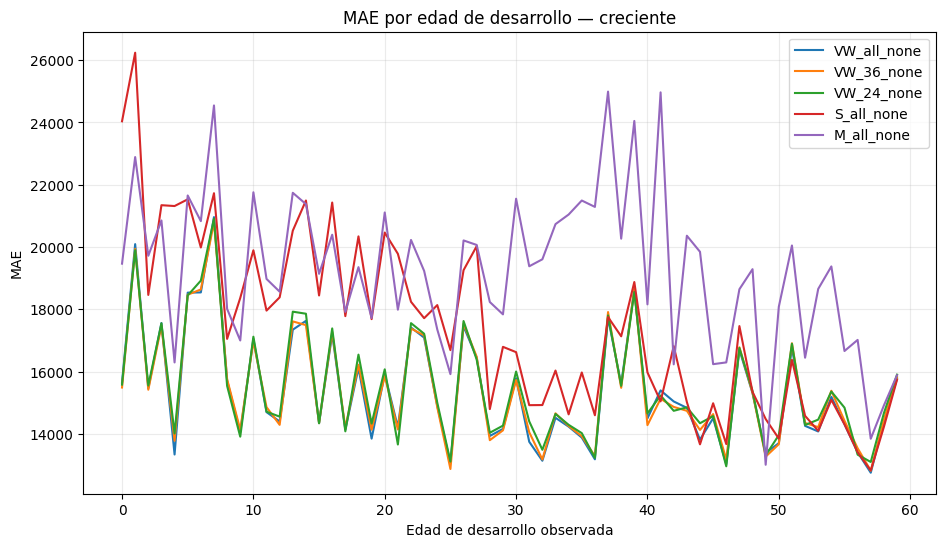

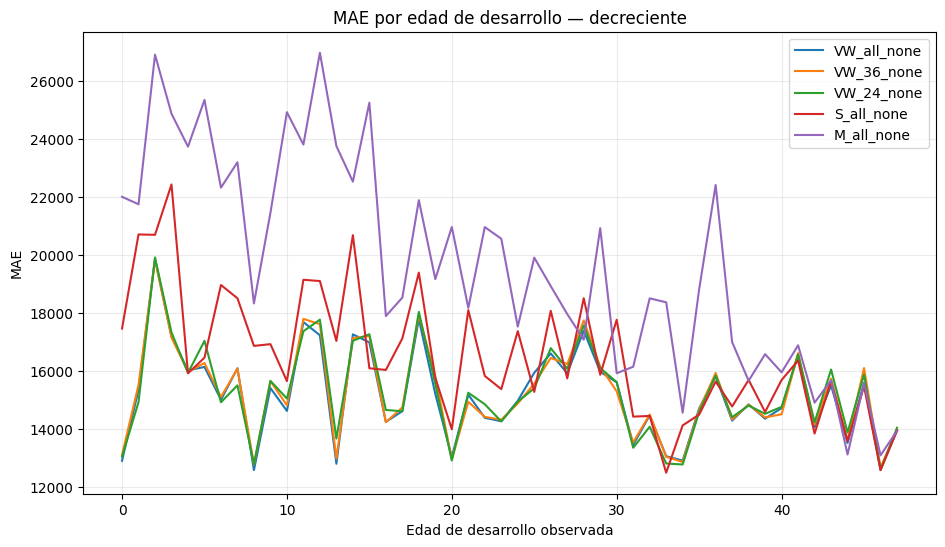

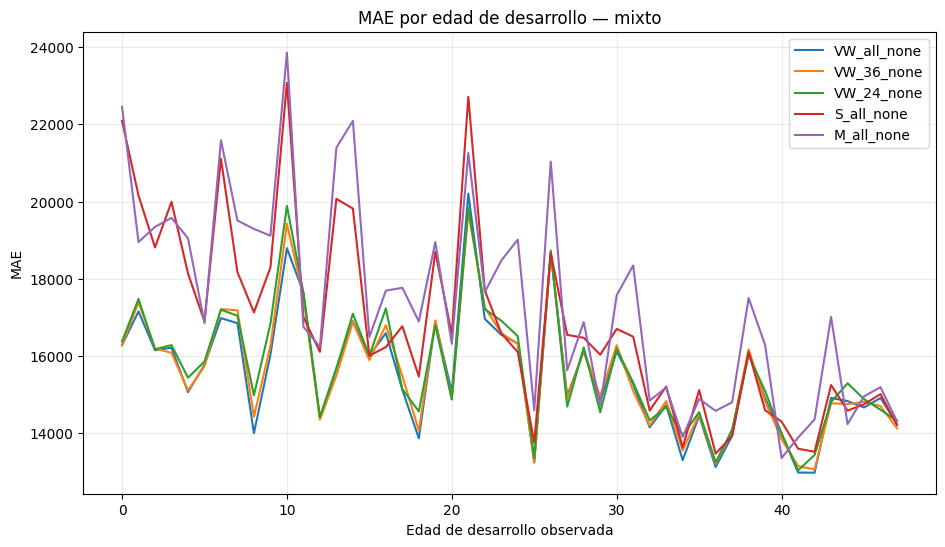

In [51]:
import matplotlib.pyplot as plt

for scenario_name in SCENARIOS:

    subset = (
        representative_age_metrics.loc[
            representative_age_metrics[
                "scenario"
            ] == scenario_name
        ]
    )

    fig, ax = plt.subplots(
        figsize=(11, 6)
    )

    for method_name in representative_methods:

        method_data = (
            subset.loc[
                subset["method_name"]
                == method_name
            ]
            .sort_values(
                "snapshot_dev_month"
            )
        )

        ax.plot(
            method_data[
                "snapshot_dev_month"
            ],
            method_data["mae"],
            label=method_name,
        )

    ax.set_title(
        f"MAE por edad de desarrollo — {scenario_name}"
    )
    ax.set_xlabel(
        "Edad de desarrollo observada"
    )
    ax.set_ylabel(
        "MAE"
    )
    ax.legend()
    ax.grid(
        alpha=0.25
    )

    plt.show()

La expectativa estructural es que el error disminuya conforme aumenta la edad de
desarrollo, ya que el monto observado se encuentra cada vez más cerca de
`dev_M`. Lo importante será revisar si las curvas mantienen el mismo orden en
todo el horizonte o si existen cruces entre métodos, especialmente en las
edades jóvenes donde la proyección restante es mayor.

### 8.3 Edades de referencia

In [52]:
selected_age_rows = []

for scenario_name in SCENARIOS:

    candidate_ages = [
        0,
        6,
        12,
        24,
        36,
        DEV_M[scenario_name] - 1,
    ]

    valid_ages = sorted(
        {
            age
            for age in candidate_ages
            if 0 <= age < DEV_M[
                scenario_name
            ]
        }
    )

    subset = (
        age_metrics.loc[
            (
                age_metrics["scenario"]
                == scenario_name
            )
            &
            (
                age_metrics[
                    "method_name"
                ] == "VW_all_none"
            )
            &
            (
                age_metrics[
                    "snapshot_dev_month"
                ].isin(valid_ages)
            )
        ]
        .copy()
    )

    selected_age_rows.append(
        subset
    )

vw_reference_by_age = pd.concat(
    selected_age_rows,
    ignore_index=True,
)

display(
    vw_reference_by_age[
        [
            "scenario",
            "snapshot_dev_month",
            "n_predictions",
            "mae",
            "rmse",
            "mape",
            "bias",
            "relative_bias",
        ]
    ]
)

,scenario,snapshot_dev_month,n_predictions,mae,rmse,mape,bias,relative_bias
0,creciente,0,71,15649.733655,20225.486631,0.011727,2481.376479,0.001721
1,creciente,6,71,18543.816073,23609.638573,0.013688,-5253.990754,-0.004012
2,creciente,12,71,14402.171531,18313.900952,0.011123,2192.031132,0.001693
3,creciente,24,71,14901.930657,18263.044416,0.012069,447.488412,0.000292
4,creciente,36,71,13187.443207,16945.893510,0.010986,1856.617730,0.001591
5,creciente,59,71,15775.036648,20021.409110,0.013938,-287.789498,-0.000230
6,decreciente,0,71,12897.479729,17040.308296,0.009395,-617.173257,-0.000494
7,decreciente,6,71,15004.935952,18730.105633,0.011240,1357.461573,0.001009
8,decreciente,12,71,17228.321523,21837.691122,0.013093,-420.767538,-0.000070
9,decreciente,24,71,14967.561764,19147.141383,0.011894,2560.697965,0.002149


Esta tabla permite cuantificar cuánto disminuye el error de una misma metodología
a medida que aumenta la información observada. También servirá como referencia
directa para la comparación posterior con los modelos de Machine Learning en
las mismas edades.

### 8.4 Alternativa con menor MAE en cada edad

In [53]:
best_method_by_age = (
    age_metrics
    .sort_values(
        [
            "scenario",
            "snapshot_dev_month",
            "mae",
        ]
    )
    .groupby(
        [
            "scenario",
            "snapshot_dev_month",
        ],
        as_index=False,
        observed=True,
    )
    .first()
)

display(
    best_method_by_age[
        [
            "scenario",
            "snapshot_dev_month",
            "method_name",
            "mae",
            "mape",
            "relative_bias",
        ]
    ]
    .head(20)
)

,scenario,snapshot_dev_month,method_name,mae,mape,relative_bias
0,creciente,0,VW_36_none,15491.415662,0.011621,0.001257
1,creciente,1,VW_12_none,19857.977261,0.014867,0.001202
2,creciente,2,VW_36_none,15421.414783,0.011543,-0.003936
3,creciente,3,VW_36_none,17471.995457,0.013112,-0.000023
4,creciente,4,VW_all_none,13341.512750,0.010019,0.003316
5,creciente,5,VW_24_none,18446.738849,0.013969,-0.001685
6,creciente,6,VW_all_none,18543.816073,0.013688,-0.004012
7,creciente,7,VW_6_none,19924.111683,0.014980,-0.003448
8,creciente,8,VW_24_none,15542.894374,0.011934,-0.001867
9,creciente,9,VW_24_none,13914.009655,0.010641,0.000392


In [54]:
age_lead_counts = (
    best_method_by_age
    .groupby(
        [
            "scenario",
            "method_name",
        ],
        observed=True,
    )
    .size()
    .rename(
        "n_ages_with_lowest_mae"
    )
    .reset_index()
    .sort_values(
        [
            "scenario",
            "n_ages_with_lowest_mae",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

display(
    age_lead_counts
)

,scenario,method_name,n_ages_with_lowest_mae
11,creciente,VW_all_none,17
8,creciente,VW_36_none,15
6,creciente,VW_24_none,8
2,creciente,S_all_none,4
4,creciente,VW_12_none,4
5,creciente,VW_24_minmax,3
9,creciente,VW_6_none,2
12,creciente,VW_all_std2,2
0,creciente,S_24_minmax,1
1,creciente,S_24_none,1


El conteo anterior es una descripción de estabilidad por edad, no un criterio de
selección automática. Una alternativa puede presentar el menor MAE en muchas
edades por diferencias muy pequeñas, mientras otra puede aportar una ventaja
material en las edades más difíciles.

Por ello, el análisis debe combinar:

- magnitud del error;
- edad de desarrollo;
- estabilidad temporal;
- sesgo.

El siguiente paso será estudiar la **evolución temporal del error** para
determinar si las diferencias observadas son persistentes o dependen de
valuaciones particulares.

## 9. Backtesting de Machine Learning

Los modelos de Machine Learning se evalúan bajo exactamente el mismo protocolo
cronológico utilizado por Desarrollo.

Se utilizan tres modelos:

- Ridge;
- Random Forest;
- HistGradientBoosting.

Todos predicen directamente:

$$
target\_amount = L_M
$$

sin transformar el objetivo.

Para cada fecha histórica:

1. se construye el mismo `train_snapshot`;
2. se construye el mismo `prediction_snapshot`;
3. los modelos se entrenan exclusivamente con información histórica;
4. se generan y congelan las predicciones;
5. posteriormente se revela `target_amount`;
6. se calculan las mismas métricas utilizadas para Desarrollo.

In [55]:
from src.experiment.backtesting import (
    run_development_backtest_valuation,
    run_development_backtest_experiment,
    run_ml_backtest_experiment,
)

from src.models.machine_learning import (
    ML_MODEL_NAMES,
)

In [56]:
ml_experiment = (
    run_ml_backtest_experiment(
        simulations_base,
        scenarios=SCENARIOS,
        valuation_periods=VALUATION_PERIODS,
        dev_M_by_scenario=DEV_M,
        model_names=ML_MODEL_NAMES,
        final_period=FINAL_PERIOD,
        random_state=42,
    )
)

In [57]:
print(
    "Valuaciones:",
    len(
        ml_experiment
        .valuation_summary
    ),
)

print(
    "Resultados modelo-valuación:",
    len(
        ml_experiment
        .valuation_metrics
    ),
)

print(
    "Predicciones evaluadas:",
    len(
        ml_experiment
        .evaluated_predictions
    ),
)

Valuaciones: 213
Resultados modelo-valuación: 639
Predicciones evaluadas: 33228


In [58]:
display(
    ml_experiment
    .valuation_metrics
    .head(20)
)

,scenario,model_valuation_period,method_name,n_predictions,mae,rmse,mape,bias,relative_bias
0,creciente,2020-01,ML_hist_gradient_boosting,60,111442.108630,136965.635211,0.096120,-86104.893082,-0.069078
1,creciente,2020-01,ML_random_forest,60,111442.108630,136965.635211,0.096120,-86104.893082,-0.069078
2,creciente,2020-01,ML_ridge,60,111442.108630,136965.635211,0.096120,-86104.893082,-0.069078
3,creciente,2020-02,ML_hist_gradient_boosting,60,129969.404676,160663.137143,0.111453,-106778.150283,-0.086653
4,creciente,2020-02,ML_random_forest,60,134529.553861,166072.838622,0.114746,-119998.661591,-0.099078
5,creciente,2020-02,ML_ridge,60,163429.872790,204914.247003,0.141277,-122690.137003,-0.098813
6,creciente,2020-03,ML_hist_gradient_boosting,60,121916.845151,153834.628274,0.103932,-105191.936202,-0.085996
7,creciente,2020-03,ML_random_forest,60,102957.722832,128259.586649,0.089443,-64637.709947,-0.049483
8,creciente,2020-03,ML_ridge,60,676112.205400,850196.241639,0.634089,619514.289479,0.586902
9,creciente,2020-04,ML_hist_gradient_boosting,60,113288.711204,140993.361325,0.096701,-95438.534344,-0.078006


## 10. Backtesting de modelos GLM

Los modelos estadísticos se evalúan bajo exactamente el mismo protocolo
cronológico utilizado por Desarrollo y Machine Learning.

Se consideran dos especificaciones:

- `GLM_gamma_log`: distribución Gamma con link log;
- `GLM_gaussian_identity`: distribución Gaussian con link identidad.

Ambos modelos predicen directamente:

$$
target\_amount = L_M
$$

sin transformar manualmente el objetivo.

Además, utilizan las mismas variables explicativas empleadas por los modelos
de Machine Learning:

- edad de desarrollo;
- fracción del desarrollo observado;
- Loss Incurred observado;
- año de ocurrencia;
- estacionalidad mensual.

Para cada fecha histórica se utilizan los mismos `train_snapshot` y
`prediction_snapshot`, y posteriormente se aplican las mismas etapas de
congelamiento, revelación del target y evaluación.

In [59]:
from src.experiment.backtesting import (
    run_development_backtest_valuation,
    run_development_backtest_experiment,
    run_ml_backtest_experiment,
    run_glm_backtest_experiment,
)

from src.models.machine_learning import (
    ML_MODEL_NAMES,
)

from src.models.glm import (
    GLM_MODEL_NAMES,
)

In [60]:
glm_experiment = (
    run_glm_backtest_experiment(
        simulations_base,
        scenarios=SCENARIOS,
        valuation_periods=VALUATION_PERIODS,
        dev_M_by_scenario=DEV_M,
        model_names=GLM_MODEL_NAMES,
        final_period=FINAL_PERIOD,
    )
)

In [61]:
print(
    "Valuaciones:",
    len(
        glm_experiment
        .valuation_summary
    ),
)

print(
    "Resultados modelo-valuación:",
    len(
        glm_experiment
        .valuation_metrics
    ),
)

print(
    "Predicciones evaluadas:",
    len(
        glm_experiment
        .evaluated_predictions
    ),
)

Valuaciones: 213
Resultados modelo-valuación: 426
Predicciones evaluadas: 22152


In [62]:
assert (
    len(
        glm_experiment
        .valuation_summary
    )
    == 213
)

assert (
    len(
        glm_experiment
        .valuation_metrics
    )
    == 426
)

assert (
    glm_experiment
    .valuation_metrics[
        "method_name"
    ]
    .nunique()
    == 2
)

print("✓ Backtesting GLM completo")

✓ Backtesting GLM completo


In [63]:
display(
    glm_experiment
    .valuation_metrics
    .head(20)
)

,scenario,model_valuation_period,method_name,n_predictions,mae,rmse,mape,bias,relative_bias
0,creciente,2020-01,GLM_gamma_log,60,1.114421e+05,1.369656e+05,0.096120,-8.610489e+04,-0.069078
1,creciente,2020-01,GLM_gaussian_identity,60,1.114421e+05,1.369656e+05,0.096120,-8.610489e+04,-0.069078
2,creciente,2020-02,GLM_gamma_log,60,1.629526e+05,2.035679e+05,0.141041,-1.194801e+05,-0.095856
3,creciente,2020-02,GLM_gaussian_identity,60,1.638790e+05,2.054728e+05,0.141678,-1.228682e+05,-0.098941
4,creciente,2020-03,GLM_gamma_log,60,1.782319e+06,2.435463e+06,1.671377,1.720993e+06,1.620155
5,creciente,2020-03,GLM_gaussian_identity,60,8.234023e+05,1.035694e+06,0.772065,7.620763e+05,0.720843
6,creciente,2020-04,GLM_gamma_log,60,1.403267e+05,1.696518e+05,0.129561,7.631982e+04,0.077632
7,creciente,2020-04,GLM_gaussian_identity,60,1.316757e+05,1.588761e+05,0.121915,6.605241e+04,0.068724
8,creciente,2020-05,GLM_gamma_log,60,1.078890e+05,1.284343e+05,0.096004,-1.052207e+05,-0.093661
9,creciente,2020-05,GLM_gaussian_identity,60,1.132391e+05,1.335282e+05,0.101383,-1.108117e+05,-0.099214


In [64]:
assert (
    "target_amount"
    not in glm_experiment
    .frozen_predictions
    .columns
)

assert (
    "target_amount"
    in glm_experiment
    .evaluated_predictions
    .columns
)

print("✓ target_amount permanece oculto durante la predicción GLM")

✓ target_amount permanece oculto durante la predicción GLM


In [65]:
assert "target_amount" not in ml_experiment.frozen_predictions.columns
assert "target_amount" in ml_experiment.evaluated_predictions.columns

assert "target_amount" not in glm_experiment.frozen_predictions.columns
assert "target_amount" in glm_experiment.evaluated_predictions.columns

In [66]:
print(
    "Development:",
    development_experiment.valuation_metrics["method_name"].nunique()
)

print(
    "ML:",
    ml_experiment.valuation_metrics["method_name"].nunique()
)

print(
    "GLM:",
    glm_experiment.valuation_metrics["method_name"].nunique()
)

Development: 21
ML: 3
GLM: 2


In [67]:
# ============================================================
# Validación final: mismo universo de evaluación
# ============================================================

COMPARISON_KEY = [
    "scenario",
    "model_valuation_period",
    "accident_period",
]


def get_evaluation_keys(experiment):
    return (
        experiment
        .evaluated_predictions[
            COMPARISON_KEY
        ]
        .drop_duplicates()
        .sort_values(
            COMPARISON_KEY
        )
        .reset_index(
            drop=True
        )
    )


development_keys = (
    get_evaluation_keys(
        development_experiment
    )
)

ml_keys = (
    get_evaluation_keys(
        ml_experiment
    )
)

glm_keys = (
    get_evaluation_keys(
        glm_experiment
    )
)


pd.testing.assert_frame_equal(
    development_keys,
    ml_keys,
)

pd.testing.assert_frame_equal(
    development_keys,
    glm_keys,
)


print(
    "✓ Universo común de evaluación:",
    f"{len(development_keys):,}",
    "combinaciones escenario-valuación-cohorte",
)

print(
    "✓ Métodos evaluados:",
    21 + 3 + 2,
)

print(
    "✓ Development, GLM y ML son directamente comparables"
)

✓ Universo común de evaluación: 11,076 combinaciones escenario-valuación-cohorte
✓ Métodos evaluados: 26
✓ Development, GLM y ML son directamente comparables


## 11. Cierre del backtesting

El protocolo de backtesting cronológico quedó implementado para las tres familias de modelos consideradas en el experimento: Métodos de Desarrollo, modelos GLM y modelos de Machine Learning.

En total se evaluaron 26 métodos bajo una estructura común:

- 21 alternativas del Método de Desarrollo;
- 2 especificaciones GLM;
- 3 modelos de Machine Learning.

Las tres familias utilizan las mismas fechas históricas de valuación y el mismo universo de cohortes inmaduras. Para cada valuación, los modelos se ajustan utilizando exclusivamente la información disponible en ese momento, generan sus predicciones y estas se congelan antes de revelar `target_amount`.

El experimento comprende 213 combinaciones escenario-valuación. Cada método genera predicciones sobre las mismas 11,076 combinaciones escenario-valuación-cohorte, lo que permite que las comparaciones posteriores se realicen sobre una base homogénea.

La inclusión de targets cuyo `target_period` ocurre después de `FINAL_PERIOD` permite conservar las edades jóvenes dentro del backtesting. `FINAL_PERIOD` se mantiene únicamente como variable diagnóstica y no determina la elegibilidad de una predicción.

Las primeras fechas históricas presentan además una condición natural de *cold start*: el número de cohortes maduras disponibles para entrenamiento es reducido y algunos modelos muestran mayor inestabilidad. Este comportamiento forma parte del experimento y deberá considerarse al estudiar la evolución temporal del error.

Dentro de las alternativas de Desarrollo se observa descriptivamente un mejor comportamiento de la familia ponderada por volumen (`VW`), con `VW_all_none` mostrando el menor MAE promedio entre las alternativas actuariales en los tres escenarios. Esta observación no constituye todavía una selección definitiva.

En esta etapa tampoco se establece una conclusión sobre la superioridad relativa de Development, GLM o Machine Learning. El objetivo del presente notebook es construir y validar el mecanismo de backtesting y generar predicciones históricas comparables.

La siguiente etapa utilizará estos resultados para analizar desempeño agregado, estabilidad temporal, comportamiento por edad de desarrollo y sesgo, y posteriormente seleccionar las alternativas que continuarán a la etapa final del experimento.

## 12. Exportación de resultados para evaluación y selección

El backtesting ha generado las predicciones y métricas necesarias para comparar
las tres familias de modelos bajo el mismo protocolo experimental.

En este apartado se almacenan las salidas finales que serán utilizadas en el
notebook `05_evaluacion_seleccion.ipynb`.

Se guardan dos niveles de información:

- **Predicciones evaluadas:** resultados a nivel escenario, valuación, cohorte y
  modelo. Permiten analizar errores, sesgo y comportamiento por edad de desarrollo.
- **Métricas por valuación:** resumen del desempeño de cada modelo en cada fecha
  histórica de valuación.

De esta forma, el notebook 05 se limita a la evaluación y selección de modelos,
sin necesidad de volver a ejecutar el backtesting.

In [68]:
from pathlib import Path

BACKTEST_RESULTS_DIR = PROJECT_ROOT / "data" / "processed" / "backtesting"
BACKTEST_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Directorio de resultados: {BACKTEST_RESULTS_DIR}")

Directorio de resultados: c:\Users\derec\Desktop\Proyectos\Modelado_Reservas_ML_vs_metodos_Actuariales\data\processed\backtesting


In [71]:
# ============================================================
# CONSOLIDACIÓN DE RESULTADOS DEL BACKTESTING
# ============================================================

evaluated_predictions = pd.concat(
    [
        development_experiment.evaluated_predictions,
        glm_experiment.evaluated_predictions,
        ml_experiment.evaluated_predictions,
    ],
    ignore_index=True,
)

valuation_metrics = pd.concat(
    [
        development_experiment.valuation_metrics,
        glm_experiment.valuation_metrics,
        ml_experiment.valuation_metrics,
    ],
    ignore_index=True,
)

print("Predicciones evaluadas:", evaluated_predictions.shape)
print("Métricas por valuación:", valuation_metrics.shape)

Predicciones evaluadas: (287976, 21)
Métricas por valuación: (5538, 9)


In [74]:
print("Columnas de evaluated_predictions:")
print(evaluated_predictions.columns.tolist())

print("\nColumnas de valuation_metrics:")
print(valuation_metrics.columns.tolist())

Columnas de evaluated_predictions:
['scenario', 'accident_period', 'snapshot_period', 'model_valuation_period', 'snapshot_dev_month', 'dev_M', 'observed_amount', 'max_feature_dev_month', 'development_cdf', 'prediction', 'method_family', 'method_name', 'valuation_period', 'target_amount', 'target_period', 'target_revealed_by_experiment_end', 'error', 'absolute_error', 'squared_error', 'relative_error', 'absolute_percentage_error']

Columnas de valuation_metrics:
['scenario', 'model_valuation_period', 'method_name', 'n_predictions', 'mae', 'rmse', 'mape', 'bias', 'relative_bias']


In [75]:
# ============================================================
# VALIDACIONES PREVIAS A LA EXPORTACIÓN
# ============================================================

assert not evaluated_predictions.empty
assert not valuation_metrics.empty

# Columnas mínimas necesarias
required_prediction_cols = {
    "scenario",
    "method_family",
    "method_name",
    "valuation_period",
    "prediction",
    "target_amount",
    "error",
    "absolute_error",
    "squared_error",
    "relative_error",
    "absolute_percentage_error",
}

required_metric_cols = {
    "scenario",
    "model_valuation_period",
    "method_name",
    "n_predictions",
    "mae",
    "rmse",
    "mape",
    "bias",
    "relative_bias",
}

assert required_prediction_cols.issubset(evaluated_predictions.columns)
assert required_metric_cols.issubset(valuation_metrics.columns)

# Integridad básica
assert evaluated_predictions["scenario"].notna().all()
assert evaluated_predictions["method_name"].notna().all()
assert evaluated_predictions["method_family"].notna().all()

assert valuation_metrics["scenario"].notna().all()
assert valuation_metrics["method_name"].notna().all()

# Resumen
print("Predicciones evaluadas:", f"{len(evaluated_predictions):,}")
print("Registros de métricas:", f"{len(valuation_metrics):,}")

print(
    "\nMétodos en predicciones:",
    evaluated_predictions["method_name"].nunique(),
)

print(
    "Métodos en métricas:",
    valuation_metrics["method_name"].nunique(),
)

print(
    "\nFamilias:",
    sorted(evaluated_predictions["method_family"].unique()),
)

print(
    "Escenarios:",
    sorted(evaluated_predictions["scenario"].unique()),
)

Predicciones evaluadas: 287,976
Registros de métricas: 5,538

Métodos en predicciones: 26
Métodos en métricas: 26

Familias: ['development', 'glm', 'machine_learning']
Escenarios: ['creciente', 'decreciente', 'mixto']


#### Exportación

In [76]:
# ============================================================
# EXPORTACIÓN
# ============================================================

predictions_path = (
    BACKTEST_RESULTS_DIR / "evaluated_predictions.parquet"
)

metrics_path = (
    BACKTEST_RESULTS_DIR / "valuation_metrics.parquet"
)

evaluated_predictions.to_parquet(
    predictions_path,
    index=False,
)

valuation_metrics.to_parquet(
    metrics_path,
    index=False,
)

print("Resultados exportados correctamente.")
print(f"Predicciones: {predictions_path}")
print(f"Métricas:     {metrics_path}")

Resultados exportados correctamente.
Predicciones: c:\Users\derec\Desktop\Proyectos\Modelado_Reservas_ML_vs_metodos_Actuariales\data\processed\backtesting\evaluated_predictions.parquet
Métricas:     c:\Users\derec\Desktop\Proyectos\Modelado_Reservas_ML_vs_metodos_Actuariales\data\processed\backtesting\valuation_metrics.parquet


In [77]:
# ============================================================
# VERIFICACIÓN DE PERSISTENCIA
# ============================================================

predictions_check = pd.read_parquet(predictions_path)
metrics_check = pd.read_parquet(metrics_path)

assert predictions_check.shape == evaluated_predictions.shape
assert metrics_check.shape == valuation_metrics.shape

assert set(predictions_check.columns) == set(evaluated_predictions.columns)
assert set(metrics_check.columns) == set(valuation_metrics.columns)

print("✓ Archivos leídos correctamente.")
print(f"✓ {len(predictions_check):,} predicciones evaluadas.")
print(f"✓ {len(metrics_check):,} registros de métricas.")

✓ Archivos leídos correctamente.
✓ 287,976 predicciones evaluadas.
✓ 5,538 registros de métricas.
